Modern deep learning frameworks abstract away the mechanics of training. This notebook builds on code from the previous notebooks in the series. I will reuse model structure, binary cross-entropy loss, linear layer, ReLU and more of the code previously written.

Here I am going to explain why accuracy is not always the best metric for model measurement. We are going to work with an unbalanced fraud detection dataset where most of the transactions are fine, with only a small minority of transactions being fraudulent.

This notebook implements precision, recall and F1 score from scratch and demonstrates how threshold tuning impacts model performance, especially in imbalanced classification problems such as fraud detection.

And finally in this notebook I will show a full train, validation and test split of data.

# Importing libraries

In [ ]:
# importing libraries
import os
import sys
import random
from pathlib import Path
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

# we definitely need a stratified shuffle
# the one exception to the from scrach rule
from sklearn.model_selection import train_test_split

from dataclasses import dataclass

# Helper functions and classes

In [ ]:
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
  project_root = Path("/content/ml-from-scratch")

  if not project_root.exists():
    !git clone https://github.com/vmirchev/ml-from-scratch.git
    !pip install -e ./ml-from-scratch/
else:
  # notebook is in ROOT/notebooks/
  project_root = Path.cwd().resolve().parent

src_root = project_root / "src"

if not src_root.exists():
  raise FileNotFoundError(f"Could not find source package directory: {src_root}")

if str(src_root) not in sys.path:
  sys.path.insert(0, str(src_root))

print("Running in:", "Colab" if IN_COLAB else "Local")
print("Project root:", project_root)

from ml_from_scratch.layers import BaseLayer, LinearLayer, Dropout
from ml_from_scratch.activations import ReLU, sigmoid
from ml_from_scratch.preprocessing import ZScoreNormalization
from ml_from_scratch.losses import BinaryCrossEntropyLoss
from ml_from_scratch.utils import set_seeds, create_batches, plot_training_curves
from ml_from_scratch.model import Model

Cloning into 'ml-from-scratch'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 89 (delta 39), reused 71 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 1.63 MiB | 8.18 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Running in: Colab
Project root: /content/ml-from-scratch


# Helper functions

Before diving into the evaluation metrics, I will first define a set of helper functions to streamline the training process and keep the focus on the metrics themselves. These include functions for evaluation, single-batch training, and a wrapper function for training the model.

In [ ]:
# set seeds for reproducibility
seed = 42
set_seeds(seed)

In [ ]:
# Xavier initialization is used to maintain variance across layers when using sigmoid activation
WEIGHT_INIT = "xavier"

In [ ]:
@dataclass
class TrainingConfig:
  epochs: int
  batch_size: int
  lr: float
  scenario_name: str = ""
  threshold: float = 0.5

In [ ]:
def evaluate_binary_classification_model(model, loss_fn, cfg: TrainingConfig, X_val, y_val):
  model.eval()

  epoch_val_loss_sum = 0
  epoch_val_correct = 0
  epoch_val_total = 0

  for X_batch_val, y_batch_val in create_batches(X_val, y_val, cfg.batch_size, shuffle=False):
      logits_val = model.forward(X_batch_val)

      batch_val_loss = loss_fn.forward(logits_val, y_batch_val)
      epoch_val_loss_sum += batch_val_loss * len(y_batch_val)

      # convert probabilities to binary predictions for accuracy calculation
      val_predictions = (sigmoid(logits_val) >= cfg.threshold).astype(int).flatten()
      epoch_val_correct += np.sum(val_predictions == y_batch_val)
      epoch_val_total += len(y_batch_val)

  val_loss = epoch_val_loss_sum / epoch_val_total
  val_accuracy = epoch_val_correct / epoch_val_total

  return {"loss": val_loss, "accuracy": val_accuracy}

In [ ]:
@dataclass
class TrainDataContainer:
    X_train: np.ndarray
    y_train: np.ndarray
    X_val: np.ndarray
    y_val: np.ndarray

In [ ]:
def train_single_batch(model, loss_fn, X_batch, y_batch, cfg):
  # forward pass
  logits = model.forward(X_batch)

  # calculate the loss
  batch_loss = loss_fn.forward(logits, y_batch)

  # calculate accuracy
  # convert probabilities to binary predictions
  predictions = (sigmoid(logits) >= cfg.threshold).astype(int).flatten()
  correct_in_batch = np.sum(predictions == y_batch)
  total_in_batch = len(y_batch)

  # derivative of loss fn
  grad_logits = loss_fn.backward()

  # gradient descent
  model.backward(grad_logits)

  model.step(cfg.lr)

  return {"batch_loss": batch_loss, "correct_in_batch": correct_in_batch, "total_in_batch": total_in_batch}

In [ ]:
def train_model(model, loss_fn, cfg: TrainingConfig, data:TrainDataContainer):
  train_losses = []
  train_accuracies = []

  val_losses = []
  val_accuracies = []

  for epoch in range(cfg.epochs):

    # training phase
    model.train()
    epoch_train_loss_sum = 0
    epoch_train_correct = 0
    epoch_train_total = 0

    for X_batch, y_batch in create_batches(data.X_train, data.y_train, cfg.batch_size):

      # make a single forward pass
      batch_train_results = train_single_batch(model, loss_fn, X_batch, y_batch, cfg)

      # update metrics
      epoch_train_loss_sum += batch_train_results["batch_loss"] * batch_train_results["total_in_batch"]
      epoch_train_correct += batch_train_results["correct_in_batch"]
      epoch_train_total += batch_train_results["total_in_batch"]

    train_losses.append(epoch_train_loss_sum / epoch_train_total)
    train_accuracies.append(epoch_train_correct / epoch_train_total)

    # make an evaluation run in each epoch
    val_metrics = evaluate_binary_classification_model(model, loss_fn, cfg, data.X_val, data.y_val)
    val_losses.append(val_metrics['loss'])
    val_accuracies.append(val_metrics['accuracy'])

  return {"train_losses": train_losses, "train_accuracies": train_accuracies, "val_losses": val_losses, "val_accuracies": val_accuracies}

# Dataset


In [ ]:
# download data
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
if IN_COLAB:
    file_path = Path("creditcard.csv")
else:
    file_path = project_root / "data" / "creditcard.csv"
    file_path.parent.mkdir(parents=True, exist_ok=True)

if not os.path.exists(file_path):
  print("[Info] Downloading dataset...")
  urllib.request.urlretrieve(url, file_path)
  print("[Info] Download complete")
else:
  print("[Info] Data already downloaded")

df = pd.read_csv(file_path)

if 'Class' in df.columns:
   df = df.rename(columns={'Class': 'target'})

[Info] Downloading dataset...
[Info] Download complete


# Data distribution

I have a plot comparing the different targets.

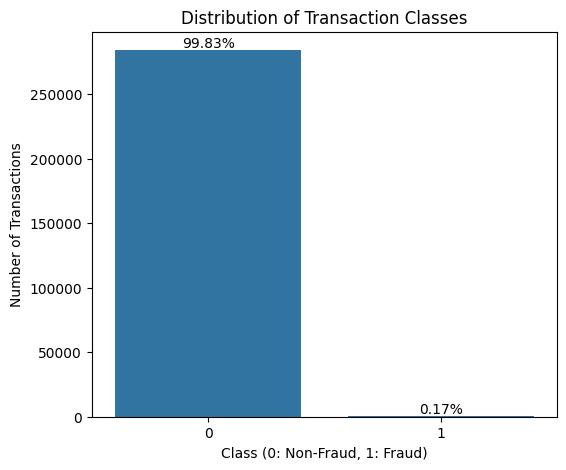

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(x='target', data=df)
plt.title('Distribution of Transaction Classes')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Number of Transactions')

total = len(df)
for p in plt.gca().patches:
    percentage = '{:.2f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    plt.gca().annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

As we can see 99.8% of transactions are non-fraud. This means that a model saying every transaction is non-fraud would achieve an accuracy of ~100%, but would be totally useless in a real-world fraud detection system.

This shows that a better evaluating metric is needed.

# Evaluation metrics

This is an image displaying different ways to evaluate a model based on predictions and ground truth.

**True Positive (TP)**

Correctly predicted positive cases.
> Model predicts Positive, and it is actually Positive.

**True Negative (TN)**

Correctly predicted negative cases.
> Model predicts Negative, and it is actually Negative.

**False Positive (FP) — Type I Error**

Incorrectly predicted positive cases.

> Model predicts Positive, but it is actually Negative.

**False Negative (FN) — Type II Error**

Incorrectly predicted negative cases.

> Model predicts Negative, but it is actually Positive.

Combined they form a **confusion matrix**, which I have shown below.

"Now here's where the confusion comes in: there is no set standard for how this matrix is structured. For example, some confusion matrices will have the predicted class in rows and the actual class in columns, or the positive class listed first and the negative class listed second." - Jessica Campbell, PhD, she also created the image.

To solve this confusion the presented image follows scikit-learn's convention.

![Different metrics](https://github.com/vmirchev/ml-from-scratch/blob/main/assets/images/precision_recall_f1_diagram.jpeg?raw=true)

This defines the following evaluation metrics:

- **Accuracy** -  Overall correctness of the model.
> Proportion of all correct predictions. Explored in every notebook up until now.

- **Precision** - How reliable positive predictions are.
> Of all predicted positives, how many are truly positive. An example would be a disease diagnosis on a rare but serious condition.

- **Recall** (Sensitivity) - How well the model detects positives.
> Of all actual positives, how many are correctly detected. Our fraud detection problem is a perfect example, or to keep to medicine - medical screening, where missing a positive case (e.g. a patient with a disease) can have serious consequences.


Now there is a metric combining Precision and Recall as they occupy the bottom left triangle of the square.

- **F1 Score** - The harmonic mean of precision and recall, balancing both metrics into a single measure.

> It is useful when you need a trade-off between precision and recall, especially in imbalanced datasets, where focusing on only one metric can be misleading. It is really important when we do **threshold experiments**.


$${\displaystyle F_{1}=2{\frac {\mathrm {precision} \cdot \mathrm {recall} }{\mathrm {precision} +\mathrm {recall} }}={\frac {2\mathrm {TP} }{2\mathrm {TP} +\mathrm {FP} +\mathrm {FN} }}}$$


For completeness
- **Specificity** - How well the model detects negatives.
> Of all actual negatives, how many are correctly identified.


# Data Load and Normalization

Here I load the data, show the shapes and normalize it.

In [ ]:
features = df.drop('target', axis=1).values
targets = df['target'].values

# first split: 80% for training, 20% for temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(features, targets,
                                                    test_size=0.2,
                                                    random_state=seed,
                                                    stratify=targets)

# second split: 50% of temp for validation, 50% of temp for test (10% val, 10% test of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
                                                  test_size=0.5,
                                                  random_state=seed,
                                                  stratify=y_temp)

print(f"Training set features shape: {X_train.shape}")
print(f"Training set target shape: {y_train.shape}")
print(f"Validation set features shape: {X_val.shape}")
print(f"Validation set target shape: {y_val.shape}")
print(f"Test set features shape: {X_test.shape}")
print(f"Test set target shape: {y_test.shape}")

Training set features shape: (227845, 30)
Training set target shape: (227845,)
Validation set features shape: (28481, 30)
Validation set target shape: (28481,)
Test set features shape: (28481, 30)
Test set target shape: (28481,)


In [ ]:
# avoiding data leakage fit to train, transform val and test
data_normalization = ZScoreNormalization()
X_train = data_normalization.fit_transform(X_train)
X_val = data_normalization.transform(X_val)
X_test = data_normalization.transform(X_test)

# Model architecture

Even a simple model can handle this dataset pretty well. The focus here is on evaluation.

In [ ]:
# create model
layers = [LinearLayer(in_features=X_train.shape[1], out_features=32),
ReLU(),
LinearLayer(in_features=32, out_features=16),
ReLU(),
LinearLayer(in_features=16, out_features=1)]

model0 = Model(layers)

# define a loss function
loss_fn = BinaryCrossEntropyLoss()

# create a TrainingConfig instance
training_cfg_model0 = TrainingConfig(
    epochs=50,
    batch_size=256,
    lr=0.01,
    scenario_name="Model 0"
)

# create DataContainer instance
train_val_data0 = TrainDataContainer(X_train=X_train, y_train = y_train, X_val=X_val, y_val=y_val)

# train and evaluate the model
m0_metrics = train_model(model0, loss_fn, training_cfg_model0, train_val_data0)

# cleaned output for better presentation
#print(training_cfg_model0.scenario_name)
#plot_training_curves(m0_metrics["train_losses"], m0_metrics["train_accuracies"], m0_metrics["val_losses"], m0_metrics["val_accuracies"])

print(f"Final train loss: {m0_metrics["train_losses"][-1]:.4f}")
print(f"Final train accuracy: {m0_metrics["train_accuracies"][-1]:.4f}")
print(f"Final val loss: {m0_metrics["val_losses"][-1]:.4f}")
print(f"Final val accuracy: {m0_metrics["val_accuracies"][-1]:.4f}")
print(f"Generalization gap: {m0_metrics["val_losses"][-1] - m0_metrics["train_losses"][-1]:.4f}")

Final train loss: 0.0035
Final train accuracy: 0.9994
Final val loss: 0.0039
Final val accuracy: 0.9992
Generalization gap: 0.0004


As expected we reached an accuracy of 99.9%. Up until now this would be considered an amazing result. Let's inspect further with more metrics.

# Metrics implementation

Now let's define our metric functions. I have added an epsilon for numerical stability when needed.

In [ ]:
def binary_predictions_from_probs(probs, threshold=0.5):
    return (probs >= threshold).astype(int).reshape(-1)

def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-8)

def recall_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-8)

def f1_score(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 2 * precision * recall / (precision + recall + 1e-8)

In [ ]:
def evaluate_binary_model_with_metrics(model, X, y, loss_fn, threshold=0.5):
  model.eval()

  logits = model.forward(X)
  loss = loss_fn.forward(logits, y)

  y_pred = binary_predictions_from_probs(sigmoid(logits), threshold=threshold)
  y_true = np.asarray(y).reshape(-1)

  return {
      "loss": loss,
      "accuracy": accuracy_score(y_true, y_pred),
      "precision": precision_score(y_true, y_pred),
      "recall": recall_score(y_true, y_pred),
      "f1": f1_score(y_true, y_pred),
  }

# Baseline model

Before we actually do some experiments, let's define a baseline model.

In [ ]:
# always predicts 0 (non-fraudulent)
y_pred_baseline = np.zeros_like(y_val)

# evaluate baseline model
baseline_accuracy = accuracy_score(y_val, y_pred_baseline)
baseline_precision = precision_score(y_val, y_pred_baseline)
baseline_recall = recall_score(y_val, y_pred_baseline)
baseline_f1 = f1_score(y_val, y_pred_baseline)

print("\nBaseline Model Metrics (always predicts 0):")
print(f"- Accuracy: {baseline_accuracy:.4f}")
print(f"- Precision: {baseline_precision:.4f}")
print(f"- Recall: {baseline_recall:.4f}")
print(f"- F1: {baseline_f1:.4f}")

# calculate confusion matrix for baseline model
baseline_tp = np.sum((y_val == 1) & (y_pred_baseline == 1))
baseline_fp = np.sum((y_val == 0) & (y_pred_baseline == 1))
baseline_fn = np.sum((y_val == 1) & (y_pred_baseline == 0))
baseline_tn = np.sum((y_val == 0) & (y_pred_baseline == 0))

baseline_cm = np.array([[baseline_tn, baseline_fp],
                        [baseline_fn, baseline_tp]])

baseline_cm_df = pd.DataFrame(baseline_cm,
                              index=['Actual Negative', 'Actual Positive'],
                              columns=['Predicted Negative', 'Predicted Positive'])

print("\nConfusion Matrix for Baseline Model:")
baseline_cm_df


Baseline Model Metrics (always predicts 0):
- Accuracy: 0.9983
- Precision: 0.0000
- Recall: 0.0000
- F1: 0.0000

Confusion Matrix for Baseline Model:


,Predicted Negative,Predicted Positive
Actual Negative,28432,0
Actual Positive,49,0


# Initial model evaluation

In [ ]:
metrics = evaluate_binary_model_with_metrics(model0, X_val, y_val, loss_fn, threshold=0.5)

In [ ]:
print("Model Metrics (Threshold=0.5):")
for key, value in metrics.items():
  if key == "loss": continue
  print(f"- {key.replace('_', ' ').title()}: {value:.4f}")

Model Metrics (Threshold=0.5):
- Accuracy: 0.9992
- Precision: 0.7872
- Recall: 0.7551
- F1: 0.7708


Not bad for initial values. As expected Recall went up from 0.0 up to 0.75.

But let's run an experiment with different thresholds.

# Thresholds experiments

Here I run 50 experiments with threshold from 0.00 up to 1.00 in 50 increments.

In [ ]:
thresholds = np.linspace(0.00, 1.00, 51)
results_by_threshold = []

print("Evaluating model performance with different thresholds...")

for threshold in thresholds:
    metrics = evaluate_binary_model_with_metrics(model0, X_val, y_val, loss_fn, threshold=threshold)
    results_by_threshold.append({
        'threshold': threshold,
        'recall': metrics['recall'],
        'precision': metrics['precision'],
        'f1': metrics['f1'],
        'accuracy': metrics['accuracy']
    })

    # cleaned output for better presentation
    #print(f"Threshold: {threshold:.2f}, Recall: {metrics['recall']:.4f}, Precision: {metrics['precision']:.4f}, F1: {metrics['f1']:.4f}, Accuracy: {metrics['accuracy']:.4f}")

print("Evaluation is complete. Run next cell to inspect results.")

Evaluating model performance with different thresholds...
Evaluation is complete. Run next cell to inspect results.


In [ ]:
# make them into a table
results_df = pd.DataFrame(results_by_threshold)
results_df

,threshold,recall,precision,f1,accuracy
0,0.00,1.000000,0.001720,0.003435,0.001720
1,0.02,0.857143,0.328125,0.474576,0.996735
2,0.04,0.857143,0.591549,0.700000,0.998736
3,0.06,0.836735,0.661290,0.738739,0.998982
4,0.08,0.836735,0.694915,0.759259,0.999087
5,0.10,0.816327,0.689655,0.747664,0.999052
6,0.12,0.816327,0.714286,0.761905,0.999122
7,0.14,0.816327,0.727273,0.769231,0.999157
8,0.16,0.816327,0.740741,0.776699,0.999192
9,0.18,0.816327,0.754717,0.784314,0.999228


And here is a visual representation of the results.

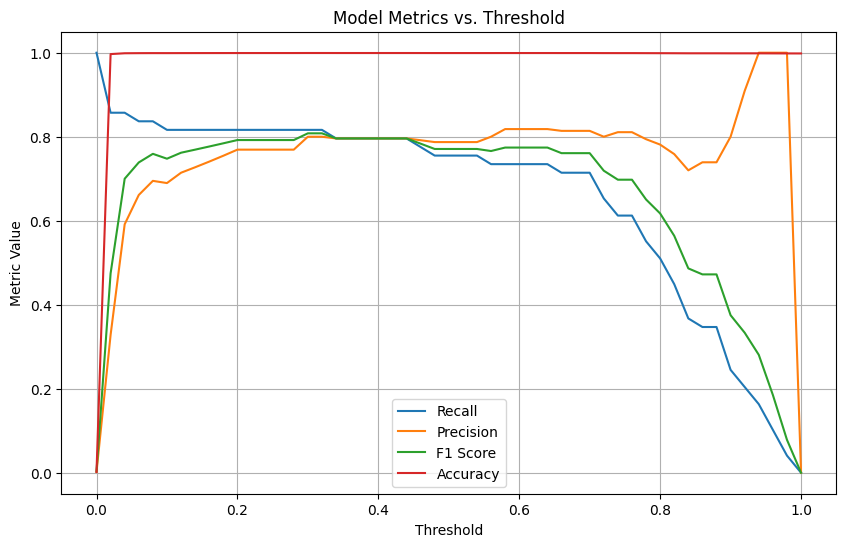

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['f1'], label='F1 Score')
plt.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title('Model Metrics vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()

The plot shows the trade-off between precision, recall and F1 score as the classification threshold varies.

As expected, recall decreases monotonically as the threshold increases. Lower thresholds classify more samples as positive, capturing more true positives but also increasing false positives.

In contrast, precision generally increases with higher thresholds, since the model becomes more conservative and only predicts positive when it is more confident.

The F1 score peaks around the mid-range thresholds (~0.3-0.5), indicating the best balance between precision and recall.

Accuracy remains artificially high across almost all thresholds, suggesting a class imbalance problem. This confirms that accuracy is not a reliable metric for this problem.

**Data observations**
> For lower thresholds (< 0.2), recall is maximized but precision drops significantly, leading to many false positives.

> For higher thresholds (> 0.7), precision improves but recall drops sharply, meaning many true positives are missed.



**Conclusions**

- A threshold around 0.25-0.35 provides the best balance (highest F1)
- A lower threshold (e.g. 0.15-0.25) may be preferred in fraud detection scenarios, where missing positives is more costly than investigating false positives
- But the flat region between ~0.20 and ~0.30 suggests threshold robustness, but selecting the point with the highest precision at constant recall provides a strictly better trade-off.

Therefore I will use 0.3265 for the test run.

# Evaluation on test set

The optimal threshold (0.32) was selected as the point that maximizes F1 score while maintaining the highest stable recall (~0.816).

Alternatively a best threshold may be automatically selected, based on F1 Score.

In [ ]:
best_idx = results_df["f1"].idxmax()
best_threshold = results_df.loc[best_idx, "threshold"]

print(f"[Info] Best threshold (by F1): {best_threshold:.4f}")

[Info] Best threshold (by F1): 0.3000


In [ ]:
result_metrics = evaluate_binary_model_with_metrics(model0, X_test, y_test, loss_fn, threshold=best_threshold)

In [ ]:
print(f"Model Metrics On Test Data (Threshold={best_threshold:.4f}):")
for key, value in result_metrics.items():
    if key == "loss": continue
    print(f"- {key.replace('_', ' ').title()}: {value:.4f}")

Model Metrics On Test Data (Threshold=0.3000):
- Accuracy: 0.9994
- Precision: 0.8163
- Recall: 0.8163
- F1: 0.8163


And now lets see an actual confusion matrix

In [ ]:
model0.eval()

logits_test = model0.forward(X_test)
loss_fn.forward(logits_test, y_test)
probs_test = sigmoid(logits_test)
y_pred_test = binary_predictions_from_probs(probs_test, threshold=best_threshold)

y_true = y_test.flatten()
y_pred = y_pred_test.flatten()

# calculate confusion matrix components manually
tp = np.sum((y_true == 1) & (y_pred == 1))
fp = np.sum((y_true == 0) & (y_pred == 1))
fn = np.sum((y_true == 1) & (y_pred == 0))
tn = np.sum((y_true == 0) & (y_pred == 0))

# create the confusion matrix array
cm = np.array([[tn, fp],
               [fn, tp]])

# Make it prettier using pandas for display
cm_df = pd.DataFrame(cm,
                     index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive'])

print(f"Confusion Matrix for Test Set (Threshold={best_threshold:.4f}):")
cm_df

Confusion Matrix for Test Set (Threshold=0.3000):


,Predicted Negative,Predicted Positive
Actual Negative,28423,9
Actual Positive,9,40


Recall improved from 0.7551 (threshold=0.5) to 0.8163 at threshold=0.32, while precision remained stable (~0.80).

The confusion matrix gives a clearer picture of model performance:

- True Positives: 40 fraudulent transactions correctly identified
- False Negatives: 9 fraudulent transactions missed
- False Positives: 9 legitimate transactions incorrectly flagged
- True Negatives: 28423 legitimate transactions correctly classified

Compared to the baseline model, which missed all 49 fraudulent transactions, the trained model successfully detects the majority of fraud cases while introducing a relatively small number of false positives.

This illustrates the core tradeoff: by lowering the threshold, we significantly increase recall (catch more fraud), at the cost of a small increase in false alerts.

There is a lot of room for improvement, but for the purpose of this notebook a recall of 0.8163 result is sufficient.

# Conclusion

Accuracy is not always a reliable evaluation metric. Depending on the problem and the cost of different types of errors, selecting the appropriate metric is essential for a meaningful assessment of model performance.

With this notebook I complete my from scratch series. An additional notebook may show up, creating different helper functions or exploring different weight initializations. It is a personal milestone project, that I am really happy to share.

I will move on to show an end-to-end ml pipeline providing a solution to a real world problem.